In [22]:
using Revise
using MajoranaPropagation
using PauliPropagation

using ForwardDiff
using Optim

using Plots 
using Random 
Random.seed!(42)

TaskLocalRNG()

In [23]:
n_spinful_sites = 20
topo = bricklayertopology(n_spinful_sites; periodic=false)
TT = getinttype(2 * n_spinful_sites)

U = 1.
t = 1.
    

H = MajoranaSum(Float64, n_spinful_sites, true)

for (i, j) in topo
    add!(H, :hopup, [i, j], -t)
    add!(H, :hopdn, [i, j], -t)
end

for i=1:n_spinful_sites 
    add!(H, :nupndn, i, U)
end

#create checkerboard fock state
fock_state = FockState(n_spinful_sites, :checkerboard, true)

Fock state with 20 fermions at positions
    ↑: 1, 3, 5, 7, 9, 11, 13, 15, 17, 19
    ↓: 2, 4, 6, 8, 10, 12, 14, 16, 18, 20


In [24]:
function lossfunction_gen(thetas; H, optim_circ, fock_state, min_abs_coeff)
    CoeffType = eltype(thetas)
    H_param = MajoranaSum(CoeffType, H.nsites, H.is_spinful)
    for (ms, coeff) in H 
        set!(H_param, ms, CoeffType(coeff))
    end
    output_H = propagate!(optim_circ, H_param, thetas; min_abs_coeff = min_abs_coeff)
    return overlapwithfock(output_H, fock_state)
end

optim_circ = []
for i=1:n_spinful_sites
    if i < n_spinful_sites
        push!(optim_circ, FermionicGate(:hopup, [i, i+1]))
        push!(optim_circ, FermionicGate(:hopdn, [i, i+1]))
    end
    push!(optim_circ, FermionicGate(:nup, i))
    push!(optim_circ, FermionicGate(:ndn, i))
end
thetas = rand(length(optim_circ))
min_abs_coeff = 1.e-5
lossfunction = θ -> lossfunction_gen(θ; H=H, optim_circ=optim_circ, fock_state=fock_state, min_abs_coeff=min_abs_coeff)

g! = (g, θ) -> ForwardDiff.gradient!(g, lossfunction, θ)


gradtol = 1.e-6
maxiter = 50

optimizer = Optim.LBFGS()
#optimizer = Optim.GradientDescent()

thetas0 = rand(length(optim_circ))

res = Optim.optimize(lossfunction, g!, thetas0, optimizer,
    Optim.Options(show_trace=true, show_every=10,store_trace=true,
        g_tol=gradtol, iterations=maxiter))

Iter     Function value   Gradient norm 
     0     4.308816e+00     1.270793e+00
 * time: 5.1975250244140625e-5
    10    -1.877066e+01     4.320354e-02
 * time: 5.154287099838257
    20    -1.878875e+01     5.434262e-03
 * time: 9.679789066314697
    30    -1.878965e+01     3.890897e-03
 * time: 14.52714490890503
    40    -1.878993e+01     4.345270e-04
 * time: 19.120625972747803
    50    -1.878993e+01     1.792028e-05
 * time: 23.640351057052612


 * Status: failure (reached maximum number of iterations)

 * Candidate solution
    Final objective value:     -1.878993e+01

 * Found with
    Algorithm:     L-BFGS

 * Convergence measures
    |x - x'|               = 2.11e-05 ≰ 0.0e+00
    |x - x'|/|x'|          = 1.64e-05 ≰ 0.0e+00
    |f(x) - f(x')|         = 2.68e-09 ≰ 0.0e+00
    |f(x) - f(x')|/|f(x')| = 1.43e-10 ≰ 0.0e+00
    |g(x)|                 = 1.79e-05 ≰ 1.0e-06

 * Work counters
    Seconds run:   24  (vs limit Inf)
    Iterations:    50
    f(x) calls:    159
    ∇f(x) calls:   159
    ∇f(x)ᵀv calls: 0


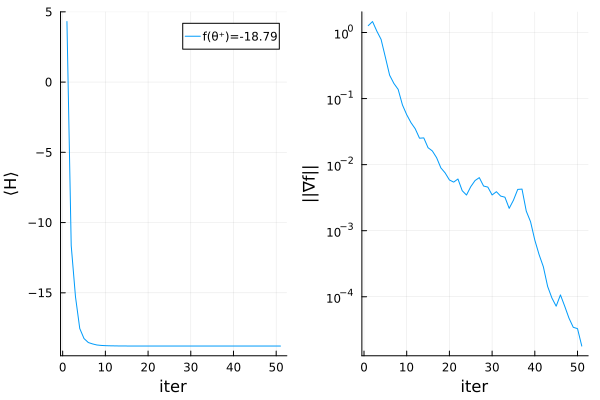

In [25]:
trace = Optim.trace(res)
f_history = [t.value for t in trace]
g_norm_history = [t.g_norm for t in trace]

energy_plot = plot(f_history, xlabel="iter", ylabel="⟨H⟩", label="f(θ⁺)=$(round(Optim.minimum(res), digits=2))")
grad_plot = plot(g_norm_history, xlabel="iter", ylabel="||∇f||", label=false, yscale=:log10)
combined_plot = plot(energy_plot, grad_plot, layout=(1,2))#, plot_title="$(n_spinful) sites, t=$t, U=$U,min_abs_coeff = $min_abs_coeff")